# **Deep Learning Lab: Transfer Learning**

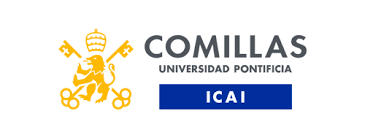

***

## Import packages

In [1]:
from cnn import CNN
import torchvision
from cnn import load_data
from cnn import load_model_weights
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import time

## Model and data loading

In [2]:
# Pytorch has many pre-trained models that can be used for transfer learning
classification_models = torchvision.models.list_models(module=torchvision.models)
print(classification_models)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [3]:
def get_best_device():
    if hasattr(torch, 'xpu') and torch.xpu.is_available():
        return torch.device('xpu')
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

device = get_best_device()
use_amp = device.type in ('cuda', 'xpu')
if device.type == 'cuda':
    amp_dtype = torch.float16
elif device.type == 'xpu':
    amp_dtype = torch.bfloat16
else:
    amp_dtype = torch.float32

print(f'Using device: {device}')
print(f'Mixed precision enabled: {use_amp} ({amp_dtype})')

Using device: cpu
Mixed precision enabled: False (torch.float32)


In [5]:
# Load data and model
train_dir = './dataset/training'
valid_dir = './dataset/validation'

train_loader, valid_loader, num_classes = load_data(train_dir,
                                                    valid_dir,
                                                    batch_size=32,
                                                    img_size=224) # ResNet50 requires 224x224 images

num_workers = min(4, os.cpu_count() or 1)
pin_memory = device.type in ('cuda', 'xpu')
persistent_workers = num_workers > 0

train_loader = DataLoader(
    train_loader.dataset,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers
  )
valid_loader = DataLoader(
    valid_loader.dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers
  )

model = CNN(torchvision.models.resnet50(weights='DEFAULT'), num_classes, device=device)

# Fine-tune the last stage of the backbone instead of only the classifier
for param in list(model.feature_extractor.children())[-1].parameters():
    param.requires_grad = True

# Materialize LazyLinear parameters before calling numel() or creating optimizer param groups
sample_images, _ = next(iter(train_loader))
with torch.no_grad():
    _ = model(sample_images[:1].to(device, non_blocking=True))

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f'Trainable parameters: {sum(p.numel() for p in trainable_params):,}')
print(f'Dataloader workers: {num_workers}, pin_memory: {pin_memory}')

Trainable parameters: 2,079,735
Dataloader workers: 4, pin_memory: False


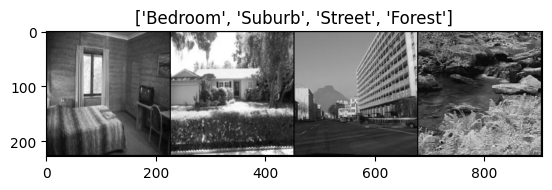

In [6]:
# Visualize a few images
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(valid_loader.dataset[i][1])
out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])

## Train

In [7]:
epochs = 1
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
criterion = nn.CrossEntropyLoss()
history = {'train_loss': [], 'train_accuracy': [], 'valid_loss': [], 'valid_accuracy': []}

use_grad_scaler = device.type == 'cuda' and use_amp
scaler = torch.cuda.amp.GradScaler(enabled=use_grad_scaler)

start_time = time.time()
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if use_grad_scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / len(train_loader.dataset)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)

    model.eval()
    valid_loss = 0.0
    valid_correct = 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            valid_loss += loss.item()
            valid_correct += (outputs.argmax(1) == labels).sum().item()

    valid_loss /= len(valid_loader)
    valid_accuracy = valid_correct / len(valid_loader.dataset)
    history['valid_loss'].append(valid_loss)
    history['valid_accuracy'].append(valid_accuracy)

    print(f'Epoch {epoch + 1}/{epochs} - Train loss: {train_loss:.4f} - Train acc: {train_accuracy:.4f}')
    print(f'Epoch {epoch + 1}/{epochs} - Valid loss: {valid_loss:.4f} - Valid acc: {valid_accuracy:.4f}')

elapsed = time.time() - start_time
print(f'Training time: {elapsed:.1f}s')

Epoch 1/1 - Train loss: 2.5406 - Train acc: 0.2482
Epoch 1/1 - Valid loss: 2.3819 - Valid acc: 0.4020
Training time: 171.3s


In [ ]:
model.save('resnet50-optimized')

## Predict

#### Load model

In [ ]:
# Load model
model_weights = load_model_weights('resnet50-optimized', device=device)
my_trained_model = CNN(torchvision.models.resnet50(weights='DEFAULT'), num_classes, device=device)
my_trained_model.load_state_dict(model_weights)

<All keys matched successfully>

## Results

In [ ]:
predicted_labels = my_trained_model.predict(valid_loader)

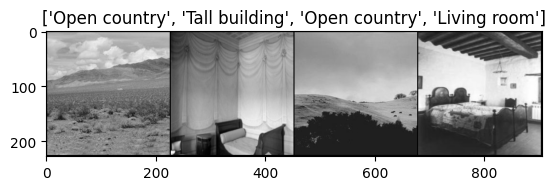

In [ ]:
# Get a few random images
random_indices = np.random.choice(len(valid_loader.dataset), size=4, replace=False)
inputs = []
classes = []
for i in random_indices:
    inputs.append(valid_loader.dataset[i][0])
    classes.append(predicted_labels[i])

out = torchvision.utils.make_grid(inputs)
classnames = train_loader.dataset.classes
imshow(out, title=[classnames[x] for x in classes])
